# All Power EEG per epoch + stage-level statistics

Recommended workflow:
1. Compute EEG total power for each 30 s epoch.
2. Keep the sleep stage for each epoch.
3. Average epochs within each patient and sleep stage.
4. Compare `control` vs `rbd` using those patient-stage means.

This notebook reads the EEG band power already saved in the `.h5` files produced by your pipeline and collapses it into one metric: `all_power_eeg`.

This avoids pseudoreplication and matches the logic already used in `statistics.ipynb`.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu, shapiro, ttest_ind

candidate_base_dirs = [Path.cwd(), *Path.cwd().parents]
base_dir = next((p for p in candidate_base_dirs if (p / "HDF files").exists()), Path.cwd())
hdf_dir = base_dir / "HDF files"
results_dir = base_dir / "Notebooks"

group_order = ["control", "rbd"]
stage_order = ["Wake", "N1", "N2", "N3", "REM"]
band_metrics = ["delta", "theta", "alpha", "beta", "gamma"]
main_power_metric = "all_power_eeg"

palette = {"control": "#4C78A8", "rbd": "#E45756"}
ci_level = 0.95
ci_resamples = 10000
ci_random_seed = 42

sns.set_theme(style="whitegrid", context="notebook")
print(f"Using HDF folder: {hdf_dir}")

Using HDF folder: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\HDF files


In [2]:
def read_value(node):
    value = node[()]
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if isinstance(value, np.generic):
        return value.item()
    return value


def maybe_read(group, key):
    return read_value(group[key]) if key in group else np.nan


def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def load_h5_eeg_power(hdf_dir: Path):
    epoch_rows = []

    for h5_path in sorted(hdf_dir.glob("*.h5")):
        try:
            with h5py.File(h5_path, "r") as f:
                if len(f.keys()) == 0:
                    print(f"Skipping empty file: {h5_path.name}")
                    continue

                patient_id = next(iter(f.keys()))
                patient = f[patient_id]
                group = str(patient.attrs.get("group", "unknown")).lower()

                if "epochs" not in patient:
                    continue

                for epoch_name, epoch in patient["epochs"].items():
                    if "eeg_bandpower" not in epoch:
                        continue

                    band_group = epoch["eeg_bandpower"]
                    row = {
                        "patient_id": patient_id,
                        "group": group,
                        "epoch": epoch_name,
                        "stage": maybe_read(epoch, "sleep_stage"),
                        "start_time": maybe_read(epoch, "start_time"),
                        "end_time": maybe_read(epoch, "end_time"),
                    }

                    for band in band_metrics:
                        row[band] = maybe_read(band_group, band)

                    epoch_rows.append(row)
        except OSError as exc:
            print(f"Skipping {h5_path.name}: {exc}")

    epoch_df = pd.DataFrame(epoch_rows)
    if epoch_df.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    for col in ["start_time", "end_time", *band_metrics]:
        epoch_df[col] = pd.to_numeric(epoch_df[col], errors="coerce")

    epoch_df["stage"] = pd.Categorical(epoch_df["stage"], categories=stage_order, ordered=True)
    epoch_df = epoch_df.sort_values(["group", "patient_id", "start_time"]).reset_index(drop=True)

    epoch_df[main_power_metric] = epoch_df[band_metrics].sum(axis=1, min_count=1)

    summary_metrics = [main_power_metric]

    patient_band_df = (
        epoch_df.groupby(["patient_id", "group"], observed=True)[summary_metrics]
        .mean(numeric_only=True)
        .reset_index()
        .sort_values(["group", "patient_id"])
        .reset_index(drop=True)
    )

    stage_df = (
        epoch_df.groupby(["patient_id", "group", "stage"], observed=True)[summary_metrics]
        .mean(numeric_only=True)
        .reset_index()
    )
    if not stage_df.empty:
        stage_df["stage"] = pd.Categorical(stage_df["stage"], categories=stage_order, ordered=True)
        stage_df = stage_df.sort_values(["stage", "group", "patient_id"]).reset_index(drop=True)

    return patient_band_df, stage_df, epoch_df


def bootstrap_ci(values, stat_fn=np.mean, confidence=ci_level, n_resamples=ci_resamples, random_seed=ci_random_seed):
    values = finite_values(values)
    if values.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(random_seed)
    samples = rng.choice(values, size=(n_resamples, values.size), replace=True)
    stats = stat_fn(samples, axis=1)
    alpha = (1 - confidence) / 2
    low, high = np.quantile(stats, [alpha, 1 - alpha])
    return float(low), float(high)


def bootstrap_mean_difference_ci(x, y, confidence=ci_level, n_resamples=ci_resamples, random_seed=ci_random_seed):
    x = finite_values(x)
    y = finite_values(y)
    if x.size == 0 or y.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(random_seed)
    x_samples = rng.choice(x, size=(n_resamples, x.size), replace=True)
    y_samples = rng.choice(y, size=(n_resamples, y.size), replace=True)
    diffs = x_samples.mean(axis=1) - y_samples.mean(axis=1)
    alpha = (1 - confidence) / 2
    low, high = np.quantile(diffs, [alpha, 1 - alpha])
    return float(low), float(high)


def cohen_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx = len(x)
    ny = len(y)
    if nx < 2 or ny < 2:
        return np.nan

    sx = np.nanstd(x, ddof=1)
    sy = np.nanstd(y, ddof=1)
    pooled = np.sqrt(((nx - 1) * sx**2 + (ny - 1) * sy**2) / (nx + ny - 2))
    if pooled == 0 or not np.isfinite(pooled):
        return np.nan

    return (np.nanmean(x) - np.nanmean(y)) / pooled


def rank_biserial_from_u(u_stat, n1, n2):
    if n1 == 0 or n2 == 0:
        return np.nan
    return 1 - (2 * u_stat) / (n1 * n2)


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan, dtype=float)
    finite = np.isfinite(p_values)
    if not finite.any():
        return adjusted

    p = p_values[finite]
    order = np.argsort(p)
    ranked = p[order]
    n = len(ranked)

    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    adjusted_finite = np.empty_like(p)
    adjusted_finite[order] = q
    adjusted[finite] = adjusted_finite
    return adjusted


def compare_groups(df, metric, group_col="group"):
    subset = df[[group_col, metric]].dropna().copy()
    control = subset.loc[subset[group_col] == "control", metric].astype(float)
    rbd = subset.loc[subset[group_col] == "rbd", metric].astype(float)

    control_ci_low, control_ci_high = bootstrap_ci(control)
    rbd_ci_low, rbd_ci_high = bootstrap_ci(rbd)
    mean_diff = control.mean() - rbd.mean()
    mean_diff_ci_low, mean_diff_ci_high = bootstrap_mean_difference_ci(control, rbd)

    row = {
        "metric": metric,
        "n_control": int(control.shape[0]),
        "n_rbd": int(rbd.shape[0]),
        "mean_control": control.mean(),
        "mean_control_ci_low": control_ci_low,
        "mean_control_ci_high": control_ci_high,
        "mean_rbd": rbd.mean(),
        "mean_rbd_ci_low": rbd_ci_low,
        "mean_rbd_ci_high": rbd_ci_high,
        "mean_diff_control_minus_rbd": mean_diff,
        "mean_diff_ci_low": mean_diff_ci_low,
        "mean_diff_ci_high": mean_diff_ci_high,
        "median_control": control.median(),
        "median_rbd": rbd.median(),
        "sd_control": control.std(ddof=1),
        "sd_rbd": rbd.std(ddof=1),
    }

    if len(control) < 3 or len(rbd) < 3:
        row.update(
            {
                "test": "insufficient_n",
                "statistic": np.nan,
                "p_value": np.nan,
                "effect_size": np.nan,
                "effect_name": np.nan,
                "shapiro_control_p": np.nan,
                "shapiro_rbd_p": np.nan,
            }
        )
        return row

    shapiro_control_p = shapiro(control).pvalue
    shapiro_rbd_p = shapiro(rbd).pvalue
    use_t_test = (shapiro_control_p > 0.05) and (shapiro_rbd_p > 0.05)

    if use_t_test:
        stat, p_value = ttest_ind(control, rbd, equal_var=False, nan_policy="omit")
        effect_size = cohen_d(control, rbd)
        effect_name = "cohen_d"
        test_name = "welch_t"
    else:
        stat, p_value = mannwhitneyu(control, rbd, alternative="two-sided")
        effect_size = rank_biserial_from_u(stat, len(control), len(rbd))
        effect_name = "rank_biserial"
        test_name = "mann_whitney"

    row.update(
        {
            "test": test_name,
            "statistic": stat,
            "p_value": p_value,
            "effect_size": effect_size,
            "effect_name": effect_name,
            "shapiro_control_p": shapiro_control_p,
            "shapiro_rbd_p": shapiro_rbd_p,
        }
    )
    return row


def stage_stats_table(stage_df, metric):
    rows = []
    for stage in stage_order:
        stage_subset = stage_df.loc[stage_df["stage"] == stage].copy()
        if stage_subset.empty:
            continue
        row = compare_groups(stage_subset, metric)
        row["stage"] = stage
        rows.append(row)

    stats_df = pd.DataFrame(rows)
    if not stats_df.empty:
        stats_df["p_fdr_bh"] = benjamini_hochberg(stats_df["p_value"].to_numpy(dtype=float))
        stats_df = stats_df[[
            "stage",
            "metric",
            "n_control",
            "n_rbd",
            "mean_control",
            "mean_control_ci_low",
            "mean_control_ci_high",
            "mean_rbd",
            "mean_rbd_ci_low",
            "mean_rbd_ci_high",
            "mean_diff_control_minus_rbd",
            "mean_diff_ci_low",
            "mean_diff_ci_high",
            "median_control",
            "median_rbd",
            "sd_control",
            "sd_rbd",
            "test",
            "statistic",
            "p_value",
            "p_fdr_bh",
            "effect_size",
            "effect_name",
            "shapiro_control_p",
            "shapiro_rbd_p",
        ]]
    return stats_df


def save_stage_statistics(stage_df, metrics, results_dir, prefix="power_eeg_stage_level"):
    all_tables = []

    for metric in metrics:
        print(f"\nStage-level comparison for {metric}")
        stage_stats = stage_stats_table(stage_df, metric)
        display(stage_stats)

        stage_csv = results_dir / f"{prefix}_{metric}.csv"
        stage_stats.to_csv(stage_csv, index=False)
        print(f"Saved: {stage_csv}")

        if not stage_stats.empty:
            all_tables.append(stage_stats.assign(metric_name=metric))

    if all_tables:
        combined_df = pd.concat(all_tables, ignore_index=True)
        combined_csv = results_dir / f"{prefix}_all_metrics.csv"
        combined_df.to_csv(combined_csv, index=False)
        print(f"Saved: {combined_csv}")
        return combined_df

    return pd.DataFrame()


def plot_stage_metric(stage_df, metric, title=None, ylabel=None):
    plot_df = stage_df[["patient_id", "group", "stage", metric]].dropna().copy()
    if plot_df.empty:
        print(f"No stage data available for {metric}")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(
        data=plot_df,
        x="stage",
        y=metric,
        hue="group",
        order=stage_order,
        hue_order=group_order,
        palette=palette,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="stage",
        y=metric,
        hue="group",
        order=stage_order,
        hue_order=group_order,
        dodge=True,
        alpha=0.55,
        size=4,
        palette={group: "black" for group in group_order},
        ax=ax,
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[: len(group_order)], labels[: len(group_order)], title="group", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title or f"{metric} by sleep stage")
    ax.set_xlabel("Sleep stage")
    ax.set_ylabel(ylabel or metric)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

In [3]:
patient_band_df, stage_df, epoch_df = load_h5_eeg_power(hdf_dir)

print(f"Patients loaded: {patient_band_df['patient_id'].nunique() if not patient_band_df.empty else 0}")
print(f"Epoch rows: {len(epoch_df)}")
print(f"Stage rows: {len(stage_df)}")

if not stage_df.empty:
    display(stage_df.head())
    display(
        stage_df.groupby(["group", "stage"], observed=True)["patient_id"]
        .nunique()
        .rename("n_patients")
        .reset_index()
    )
else:
    print("No stage-level EEG power data found in the HDF files.")

Patients loaded: 30
Epoch rows: 32027
Stage rows: 150


,patient_id,group,stage,all_power_eeg
0,ins1,control,Wake,4.395062e-11
1,ins2,control,Wake,2.011289e-11
2,ins3,control,Wake,1.803586e-11
3,ins4,control,Wake,3.241425e-10
4,ins5,control,Wake,2.338861e-11


,group,stage,n_patients
0,control,Wake,15
1,control,N1,15
2,control,N2,15
3,control,N3,15
4,control,REM,15
5,rbd,Wake,15
6,rbd,N1,15
7,rbd,N2,15
8,rbd,N3,15
9,rbd,REM,15


This notebook now runs the statistics only for `all_power_eeg`.

Important: the original band power in `functions.py` is stored in `V²`, so the values can be very small.
If you had `round(4)`, many means / CI / SD values could appear as `0.0000` even when they are not actually zero.

If later you want to go back to separate bands, we can expand it again.

In [4]:
# Best practice: each point in stage_df is one mean per patient within one sleep stage.
stage_metrics = [main_power_metric]

all_stage_stats_df = save_stage_statistics(stage_df, stage_metrics, results_dir)
display(all_stage_stats_df)


Stage-level comparison for all_power_eeg


,stage,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,...,sd_control,sd_rbd,test,statistic,p_value,p_fdr_bh,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p
0,Wake,all_power_eeg,15,15,6.228860e-11,1.923085e-11,1.241231e-10,6.899100e-11,1.681505e-11,1.577158e-10,...,1.098475e-10,1.658241e-10,mann_whitney,129.000000,0.506915,0.506915,-0.146667,rank_biserial,0.000002,6.805458e-07
1,N1,all_power_eeg,15,15,1.940952e-11,1.407353e-11,2.521543e-11,1.440863e-11,9.524957e-12,1.988984e-11,...,1.142528e-11,1.085571e-11,mann_whitney,147.000000,0.158465,0.198081,-0.306667,rank_biserial,0.492845,4.023162e-02
2,N2,all_power_eeg,15,15,2.404449e-11,1.508434e-11,3.698648e-11,1.465022e-11,9.716601e-12,2.042061e-11,...,2.281445e-11,1.114624e-11,mann_whitney,149.000000,0.135382,0.198081,-0.324444,rank_biserial,0.000142,3.310492e-02
3,N3,all_power_eeg,15,15,2.835324e-11,1.945464e-11,3.881404e-11,1.838955e-11,1.151176e-11,2.864448e-11,...,2.003576e-11,1.813849e-11,mann_whitney,161.000000,0.046487,0.116217,-0.431111,rank_biserial,0.010765,2.854105e-05
4,REM,all_power_eeg,15,15,2.106115e-11,1.504499e-11,2.702397e-11,9.252217e-12,6.625370e-12,1.225933e-11,...,1.220265e-11,5.818362e-12,welch_t,3.383127,0.002946,0.014729,1.235343,cohen_d,0.436505,9.864578e-02


Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\power_eeg_stage_level_all_power_eeg.csv
Saved: c:\Users\carlo\OneDrive - Universidade de Lisboa\Documents\GitHub\heart-lung-brain-coupling-for-RBD\Notebooks\power_eeg_stage_level_all_metrics.csv


,stage,metric,n_control,n_rbd,mean_control,mean_control_ci_low,mean_control_ci_high,mean_rbd,mean_rbd_ci_low,mean_rbd_ci_high,...,sd_rbd,test,statistic,p_value,p_fdr_bh,effect_size,effect_name,shapiro_control_p,shapiro_rbd_p,metric_name
0,Wake,all_power_eeg,15,15,6.228860e-11,1.923085e-11,1.241231e-10,6.899100e-11,1.681505e-11,1.577158e-10,...,1.658241e-10,mann_whitney,129.000000,0.506915,0.506915,-0.146667,rank_biserial,0.000002,6.805458e-07,all_power_eeg
1,N1,all_power_eeg,15,15,1.940952e-11,1.407353e-11,2.521543e-11,1.440863e-11,9.524957e-12,1.988984e-11,...,1.085571e-11,mann_whitney,147.000000,0.158465,0.198081,-0.306667,rank_biserial,0.492845,4.023162e-02,all_power_eeg
2,N2,all_power_eeg,15,15,2.404449e-11,1.508434e-11,3.698648e-11,1.465022e-11,9.716601e-12,2.042061e-11,...,1.114624e-11,mann_whitney,149.000000,0.135382,0.198081,-0.324444,rank_biserial,0.000142,3.310492e-02,all_power_eeg
3,N3,all_power_eeg,15,15,2.835324e-11,1.945464e-11,3.881404e-11,1.838955e-11,1.151176e-11,2.864448e-11,...,1.813849e-11,mann_whitney,161.000000,0.046487,0.116217,-0.431111,rank_biserial,0.010765,2.854105e-05,all_power_eeg
4,REM,all_power_eeg,15,15,2.106115e-11,1.504499e-11,2.702397e-11,9.252217e-12,6.625370e-12,1.225933e-11,...,5.818362e-12,welch_t,3.383127,0.002946,0.014729,1.235343,cohen_d,0.436505,9.864578e-02,all_power_eeg


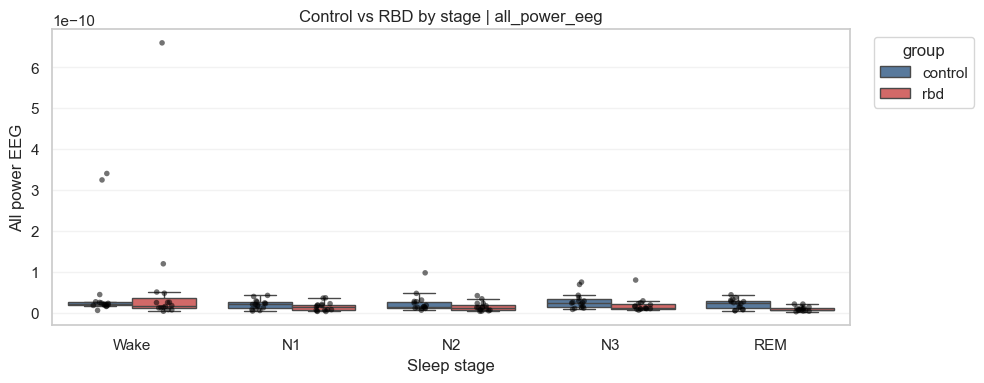

In [5]:
for metric in stage_metrics:
    plot_stage_metric(stage_df, metric, title="Control vs RBD by stage | all_power_eeg", ylabel="All power EEG")